# Import Libraries

In [41]:
import warnings
warnings.filterwarnings("ignore")

In [42]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# Get Dataset

In [59]:
# load complete mice dataset
MICE_DATASET_PATH = (
    r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
    r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
)
mice_dataset =  sc.read_h5ad(MICE_DATASET_PATH)

In [60]:
# subset Fast IIX and Fast IIB
adata = pgl.subset_adata_by_obs(mice_dataset, filters={"C_scANVI": ["Fast IIX", "Fast IIB"],
                                                        "sex": "F"})
display(adata.obs["C_scANVI"].value_counts())

C_scANVI
Fast IIX    18827
Fast IIB    14929
Name: count, dtype: int64

In [ ]:
# subset Fast IIX
# adata = pgl.subset_adata_by_obs(mice_dataset, filters={"C_scANVI": "Fast IIX", 
#                                                         "sex": "F"})
# display(adata.obs["C_scANVI"].value_counts())

C_scANVI
Fast IIX    34128
Name: count, dtype: int64

In [ ]:
# subset Fast IIB
# adata = pgl.subset_adata_by_obs(mice_dataset, filters={"C_scANVI": "Fast IIB",
#                                                         "sex": "F"})
# display(adata.obs["C_scANVI"].value_counts())

C_scANVI
Fast IIB    33378
Name: count, dtype: int64

# Get Geneset

In [61]:
# mice all pathways path
MICE_ALL_PATHWAYS = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

# specify pathway
pathway = "REACTOME_PYRUVATE_METABOLISM"

# load pathway genes
pathway_genes = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS, include_pathways=[pathway], gene_origin="mice")
display(len(pathway_genes))
display(pathway_genes.head())

45

,source,target
0,REACTOME_PYRUVATE_METABOLISM,Armc8
1,REACTOME_PYRUVATE_METABOLISM,Dlat
2,REACTOME_PYRUVATE_METABOLISM,Dld
3,REACTOME_PYRUVATE_METABOLISM,Fahd1
4,REACTOME_PYRUVATE_METABOLISM,Gid4


In [62]:
# check if genes are in adata
genes_in_adata = pgl.check_genes_in_adata(pathway_genes, adata)
display(genes_in_adata.keys())
display(genes_in_adata["genes_found_in_adata"])

dict_keys(['total_genes_checked', 'genes_found_in_adata', 'genes_missing_from_adata', 'matched_genes', 'missing_genes'])

4

# Calculate Scores

In [63]:
%%time

# get scores
dc.mt.aucell(
    adata,
    pathway_genes,
    raw=False,
    verbose=True,
    tmin = 4 # only 4 common genes are present
)

2026-05-14 08:46:35 | [INFO] aucell - Running aucell
2026-05-14 08:46:35 | [INFO] Extracted omics mat with 33756 rows (observations) and 3000 columns (features)
2026-05-14 08:46:35 | [WARNING] 16 features of mat are empty, they will be removed
2026-05-14 08:46:35 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-14 08:46:35 | [INFO] Network has 4 unique features and 1 unique sources
2026-05-14 08:46:35 | [INFO] aucell - calculating 1 AUCs for 2984 targets across 33756 observations, categorizing features at rank=150
100%|██████████| 33756/33756 [00:07<00:00, 4812.55it/s]
2026-05-14 08:46:42 | [INFO] aucell - done


CPU times: user 7min 26s, sys: 171 ms, total: 7min 26s
Wall time: 7.13 s


In [64]:
# store pathway scores into obs
adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()
display(adata.obs[pathway].head(10))

AAACCCAAGATTCGAA-1    0.255932
AAACCCACACTCATAG-1    0.166102
AAACCCACAGCCTTCT-1    0.172881
AAACCCACAGTATGAA-1    0.205085
AAACCCACATCATTGG-1    0.233898
AAACCCAGTCGGAAAC-1    0.261017
AAACCCAGTTAGGAGC-1    0.188136
AAACCCATCAGCCTTC-1    0.050847
AAACCCATCCGAGATT-1    0.376271
AAACCCATCGACCATA-1    0.101695
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

In [65]:
# prepare per group score
group_score = pgl.prepare_group_score_df(adata, 
                                            group_col="condition",
                                            value_col=pathway,
                                            dropna=True)
display(group_score.head())

,condition,REACTOME_PYRUVATE_METABOLISM
0,KO,0.255932
1,KO,0.166102
2,KO,0.172881
3,KO,0.205085
4,KO,0.233898


In [66]:
# get a score summary
score_summary = pgl.summarize_score_by_group(group_score,
                                            group_col="condition",
                                            score_col=pathway)
display(score_summary)

,condition,count,mean,median,std,min,max
0,KO,16387,0.126734,0.116949,0.114817,0.0,0.633898
1,WT,17369,0.076417,0.047458,0.087593,0.0,0.550847


# Calculate Cliffs Delta

In [67]:
# calculate cliffs delta
cliffs_delta, _ = pgl.calculate_score_cliffs_delta(adata,
                       pathway,
                       group_col="condition",
                       group1="WT",
                       group2="KO")
display(cliffs_delta)

,score_col,WT_count,KO_count,WT_mean,KO_mean,WT_median,KO_median,WT_std,KO_std,WT_min,KO_min,WT_max,KO_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,REACTOME_PYRUVATE_METABOLISM,17369,16387,0.076417,0.126734,0.047458,0.116949,0.087593,0.114817,0.0,0.0,0.550847,0.633898,-0.050318,-0.069492,-0.252706,0.252706,KO


# Plot

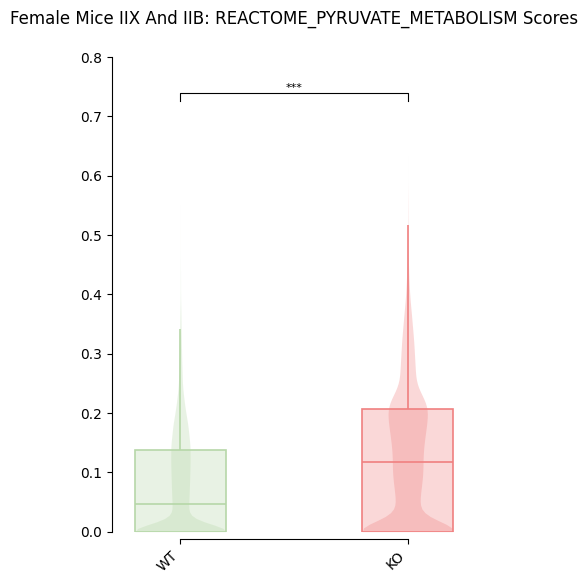

<Figure size 640x480 with 0 Axes>

In [68]:
# choose order
sample_order = ["WT", "KO"]

# palette keys must match age_label values
palette = {
    "WT": "#B6D7A8",
    "KO": "#F08080"
}

# plot violin box plot
fig_violin_box = pgl.plot_violin_box_combo(group_score,
                                           x_var="condition",
                                           y_var=pathway,
                                           title=f"Female Mice IIX And IIB: {pathway} Scores",
                                           palette=palette,
                                           x_ticks=sample_order,
                                           show_scatter=False)

display(fig_violin_box)

In [69]:
# subset wt and get gene correlation
adata_wt = pgl.subset_adata_by_obs(adata, filters={"condition": "WT"})
ranked_genes_wt = pgl.compute_gene_correlation_against_score(adata_wt, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_wt.head())

# subset ko and get gene correlation
adata_ko = pgl.subset_adata_by_obs(adata, filters={"condition": "KO"})
ranked_genes_ko = pgl.compute_gene_correlation_against_score(adata_ko, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_ko.head())

,gene,spearman_corr,rank
0,Me3,0.618522,1
1,Pdk4,0.455626,2
2,Pcx,0.218525,3
3,Ldhb,0.102005,4


,gene,spearman_corr,rank
0,Pdk4,0.722553,1
1,Me3,0.434478,2
2,Pcx,0.302765,3
3,Ldhb,0.105996,4


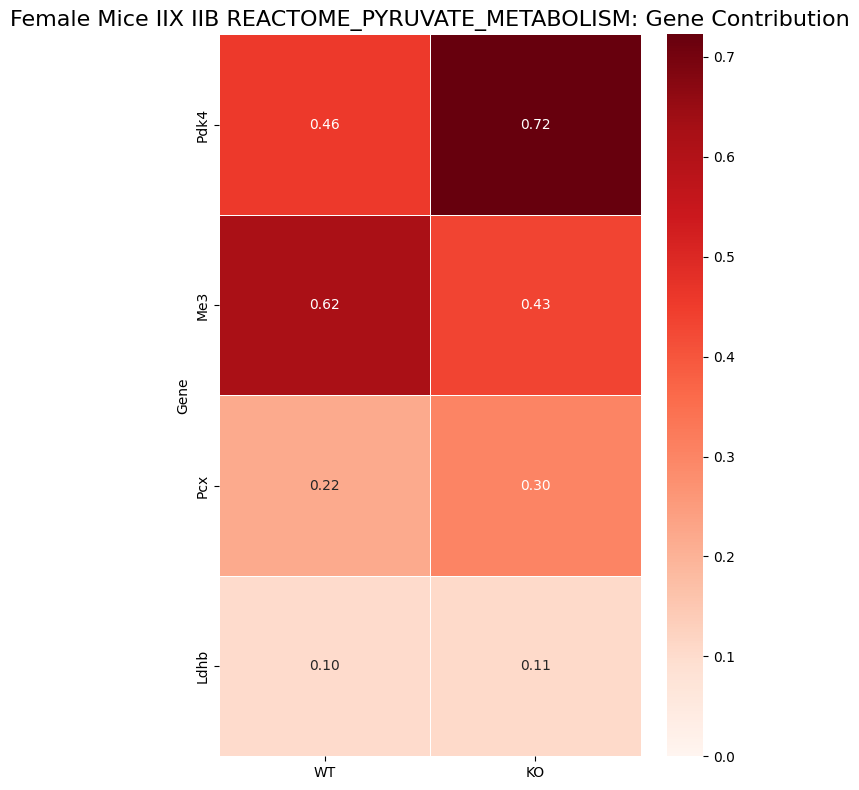

In [56]:
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_wt,
     "KO": ranked_genes_ko},
     title=f"Female Mice IIX IIB {pathway}: Gene Contribution"
)

# Save

saved: Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/F_Mice_IIX_IIB_REACTOME_PYRUVATE_METABOLISM_Violin_Box_SVG.svg
saved: Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/F_Mice_IIX_IIB_REACTOME_PYRUVATE_METABOLISM_Violin_Box_PNG.png
saved: Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/F_Mice_IIX_IIB_REACTOME_PYRUVATE_METABOLISM_Gene_Contribution_Heatmap_SVG.svg
saved: Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/F_Mice_IIX_IIB_REACTOME_PYRUVATE_METABOLISM_Gene_Contribution_Heatmap_PNG.png


PosixPath('Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/Cliffs_Delta_SVG.svg')

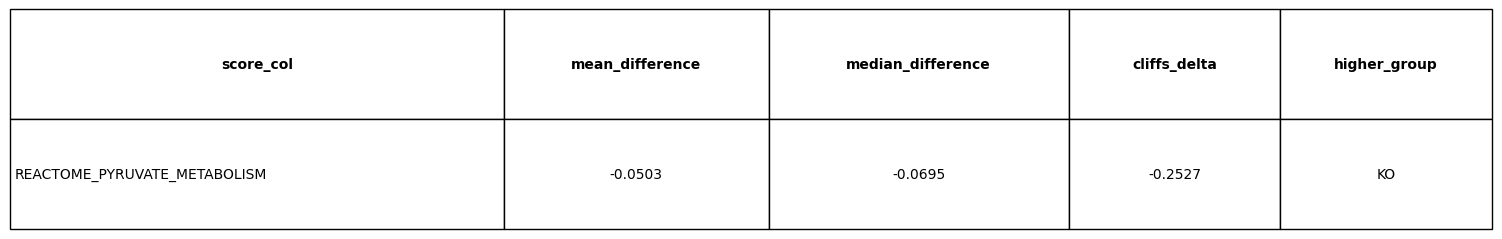

In [78]:
# save image

from pathlib import Path

# figures to save
figures_to_save = {
    "Violin_Box": fig_violin_box,
    "Gene_Contribution_Heatmap": fig_gene_contribution_heatmap
}

# output folder
output_dir = Path("Output/F_Mice_IIX_IIB/Pyruvate_Metabolism")
output_dir.mkdir(parents=True, exist_ok=True)


# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"F_Mice_IIX_IIB_{pathway}_{plot_type}_SVG.svg"
    png_path = output_dir / f"F_Mice_IIX_IIB_{pathway}_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

plot_df = cliffs_delta[["score_col", "mean_difference", "median_difference", "cliffs_delta", "higher_group"]]
fig_cliffs_delta = pgl.save_df_table_image(plot_df)
pgl.save_fig_as_png(fig_cliffs_delta, "Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/Cliffs_Delta_PNG.png")
pgl.save_editable_svg(fig_cliffs_delta, "Output/F_Mice_IIX_IIB/Pyruvate_Metabolism/Cliffs_Delta_SVG.svg")